---
# Post-TARE Adoption KPIs: Bill Savings, Demand Change, NPV
---

**Author:** Jordan M. Joseph, PhD — Carnegie Mellon University

Computes adoption metrics that depend on EUSS building-level data and (optionally)
TARE model run outputs: actual bill savings, electricity demand change, and site
energy change under various adoption scenarios.

**Prerequisite:** Run the preTARE notebook first (or ensure EUSS data is loaded).

See `README_adoption_kpis.md` for methodology notes and design decisions.

---
## Step 0: Imports and Configuration
---

In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from config import PROJECT_ROOT
from cmu_tare_model.constants import (
    ALLOWED_HOUSING_TYPES,
    VALID_MENU_MPS,
    VERBOSE,
    REMDB_COST_SCENARIO_KEYS,
    RCM_MODELS,
    PRIVATE_DISCOUNT_RATE_SHORT_KEYS,
)

from cmu_tare_model.utils.column_names import (
    create_npv_col,
    create_capital_col,
)

from cmu_tare_model.utils.load_exported_results_to_df import load_measure_package_data

from cmu_tare_model.adoption_kpis.kpi_functions import (
    mp_to_upgrade,
    load_euss_baseline,
    load_euss_upgrade,
    calculate_price_ratios,
    compute_thermal_cop_by_state,
    compute_spark_gap_metrics,
    compute_scenario_demand,
    aggregate_demand_by_state,
    FUEL_PRICES_PATH,
    SHAPEFILE_PATH,
    HEATING_FUEL_COLS,
    HP_BACKUP_ELEC_COL,
    HP_FANS_PUMPS_COL,
)
from cmu_tare_model.adoption_kpis.visualize_geospatial_data import (
    prepare_state_geodataframe,
    create_choropleth_map,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)

print("✓ Imports loaded")

Project root directory: c:\users\jorda\desktop\projects\cmu-tare-model
✓ Imports loaded


---
## Step 0b: Measure Package Selection
---

In [2]:
SELECTABLE_MPS = [mp for mp in VALID_MENU_MPS if mp != 0]

try:
    _ = input_measure_package
    batch_mode = True
    selected_mps = [int(input_measure_package)]
    print(f"BATCH MODE: Running for MP{selected_mps[0]}")
except NameError:
    batch_mode = False
    print(f"Available measure packages: {SELECTABLE_MPS}")
    mp_input = input("Enter MP numbers (comma-separated, or 'all'): ").strip()
    if mp_input.lower() == 'all':
        selected_mps = SELECTABLE_MPS
    else:
        selected_mps = [int(x.strip()) for x in mp_input.split(',') if x.strip().isdigit()]
        selected_mps = [mp for mp in selected_mps if mp in SELECTABLE_MPS]
    if not selected_mps:
        selected_mps = [4]
        print("No valid MPs selected. Defaulting to MP4.")

print(f"\nSelected measure packages: {selected_mps}")

Available measure packages: [3, 4]

Selected measure packages: [4]


---
## Step 0c: Load TARE Model Data (Measure Packages 3, 4)
---

Load pre-computed TARE model outputs for the selected measure packages.
Required for Step 4d (Private NPV extraction).

If the top-section data loading cells have already been run, this will reuse `DATAFRAMES_BY_MP`.

In [3]:
# =============================================================================
# STEP 0c: LOAD TARE MODEL DATA (for NPV extraction)
# =============================================================================
# Check if DATAFRAMES_BY_MP was already loaded by the top-section cells.
# If not, prompt for the output folder and load for selected MPs.

try:
    _ = DATAFRAMES_BY_MP
    print(f"DATAFRAMES_BY_MP already loaded: {list(DATAFRAMES_BY_MP.keys())}")
except NameError:
    print("DATAFRAMES_BY_MP not found — loading TARE model outputs...")

    # Check if output_folder_path is already defined (from top section)
    try:
        _ = output_folder_path
        print(f"  Using existing output_folder_path: {output_folder_path}")
    except NameError:
        output_folder_path = os.path.join(PROJECT_ROOT, "cmu_tare_model", "output_results")
        location_id = input("Enter location ID (e.g., 'National' or 'PA'): ").strip()
        model_run_date_time = input("Enter model run timestamp (YYYY-MM-DD_HH-MM): ").strip()
        print(f"  output_folder_path: {output_folder_path}")
        print(f"  location_id: {location_id}")
        print(f"  model_run_date_time: {model_run_date_time}")

    DATAFRAMES_BY_MP = {}
    for mp in selected_mps:
        DATAFRAMES_BY_MP[mp] = load_measure_package_data(
            mp, output_folder_path, location_id, model_run_date_time
        )

    print(f"\n✓ Loaded TARE data for MPs: {list(DATAFRAMES_BY_MP.keys())}")

DATAFRAMES_BY_MP not found — loading TARE model outputs...
  output_folder_path: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\output_results
  location_id: National
  model_run_date_time: 2026-02-18_00-12
Loading MP4 data...
  fixed_base: ✓ 
MP4 loading complete!


✓ Loaded TARE data for MPs: [4]


---
## Step 1: Load EUSS Data
---

In [4]:
print("=" * 80)
print("STEP 1: LOAD EUSS DATA")
print("=" * 80)

df_baseline = load_euss_baseline()
print(f"  Baseline: {len(df_baseline):,} occupied SF homes")

upgrade_data = {}
for mp in selected_mps:
    upgrade_name = mp_to_upgrade(mp)
    print(f"\nLoading MP{mp} ({upgrade_name})...")
    upgrade_data[mp] = load_euss_upgrade(upgrade_name)
    print(f"  MP{mp}: {len(upgrade_data[mp]):,} applicable homes")

print(f"\n✓ STEP 1 COMPLETE")

STEP 1: LOAD EUSS DATA
Loading baseline from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\baseline_metadata_and_annual_results.csv
  After occupancy filter: 482,597 / 548,916
  After housing type filter (['Single-Family Attached', 'Single-Family Detached']): 331,531
  Baseline: 331,531 occupied SF homes

Loading MP4 (upgrade04)...
Loading upgrade04 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade04_metadata_and_annual_results.csv
  After occupancy filter: 482,597 / 548,916
  After housing type filter: 331,531
  After applicability filter: 331,526
  MP4: 331,526 applicable homes

✓ STEP 1 COMPLETE


---
## Step 2–4: Spark Gap and Effective Annual COP
---

These are the same computations as the preTARE notebook. They're re-run here to
produce `df_prices_csv`, `df_cop`, and `df_spark` as inputs to Step 5.

In [ ]:
df_prices_csv = calculate_price_ratios(FUEL_PRICES_PATH, year=2022)
print(f"✓ Price data: {len(df_prices_csv)} states")

cop_results = {}
for mp in selected_mps:
    cop_results[mp] = compute_thermal_cop_by_state(
        df_baseline, upgrade_data[mp], fuel_filter='Natural Gas', verbose=True
    )

primary_mp = selected_mps[0]
df_cop = cop_results[primary_mp]
df_upgrade_primary = upgrade_data[primary_mp]

df_spark = compute_spark_gap_metrics(df_prices_csv, df_cop, verbose=True)

print(f"\n✓ Steps 2–4 COMPLETE (MP{primary_mp})")

✓ Price data: 51 states
Matched homes (baseline ∩ upgrade): 331,526
Filtered to 'Natural Gas': 180,939 / 331,526 homes (54.6%)
Excluded 683 homes with zero baseline heating (180,256 remaining)

--- Thermal COP Summary (Natural Gas, by state) ---
Groups: 49
Mean:   3.89
Median: 3.98
Range:  2.15 - 5.72
⚠ 8 groups with suspicious COP (<1.5 or >5.0):
    AL: 5.06
    CA: 5.72
    FL: 5.70
    GA: 5.06
    LA: 5.35
    MS: 5.02
    SC: 5.06
    TX: 5.30

--- Baseline AFUE Summary (Natural Gas) ---
Mean:   0.80
Median: 0.80
Range:  0.75 - 0.82

--- Fan/Pump Energy as % of Total HP Electricity ---
Mean:   4.5%
Range:  2.4% - 5.7%

--- Spark Gap Metrics Summary (49 states) ---
Break-even COP @90% AFUE — Mean: 2.79, Range: 1.45–4.32
States where effective COP < break-even @90%: 14/49

✓ Steps 2–4 COMPLETE (MP4)


---
## Step 4c: Bill Savings Ratio (Per-Building → State Median)
---

Computes the actual bill savings ratio per building:
`ratio = retrofit_elec_cost / baseline_heating_cost`

Unlike the analytical `bill_impact_ratio` (spark_gap × AFUE / COP), this uses
actual per-building energy consumption and fuel-specific state prices.
Ratio < 1 = HP saves money; ratio > 1 = HP costs more.

In [6]:
# ============================================================================
# STEP 4c: BILL SAVINGS RATIO — Per-Building → State Median
# ============================================================================

print(f"===== STEP 4c: BILL SAVINGS RATIO (MP{primary_mp}, NG homes) =====")

elec_col = 'out.electricity.heating.energy_consumption.kwh'
gas_col = 'out.natural_gas.heating.energy_consumption.kwh'

# Build per-building cost table
df_ratio = pd.DataFrame({
    'state': df_baseline['in.state'],
    'heating_fuel': df_baseline['in.heating_fuel'],
    'weight': df_baseline['weight'],
    'baseline_elec_kwh': df_baseline[elec_col].fillna(0),
    'baseline_gas_kwh': df_baseline[gas_col].fillna(0),
}).join(
    pd.DataFrame({
        'retrofit_hp_kwh': df_upgrade_primary[elec_col].fillna(0),
        'retrofit_bkup_kwh': df_upgrade_primary[HP_BACKUP_ELEC_COL].fillna(0),
        'retrofit_fans_kwh': df_upgrade_primary[HP_FANS_PUMPS_COL].fillna(0),
    }),
    how='inner',
)

# Filter to natural gas homes
df_ratio = df_ratio[df_ratio['heating_fuel'] == 'Natural Gas'].copy()

# Total retrofit electricity
df_ratio['retrofit_elec_kwh'] = (
    df_ratio['retrofit_hp_kwh']
    + df_ratio['retrofit_bkup_kwh']
    + df_ratio['retrofit_fans_kwh']
)

# Join state-level fuel prices
df_ratio = df_ratio.merge(
    df_prices_csv[['state', 'elec_price_kwh', 'gas_price_kwh']],
    on='state', how='inner',
)

# Annual costs ($/year)
# ASSUMPTION: Baseline cost includes electric heating component priced at elec rate + gas at gas rate
df_ratio['baseline_annual_cost'] = (
    df_ratio['baseline_elec_kwh'] * df_ratio['elec_price_kwh']
    + df_ratio['baseline_gas_kwh'] * df_ratio['gas_price_kwh']
)
# Retrofit: all-electric
df_ratio['retrofit_annual_cost'] = (
    df_ratio['retrofit_elec_kwh'] * df_ratio['elec_price_kwh']
)

# Bill savings (positive = HP saves money)
df_ratio['annual_bill_savings'] = (
    df_ratio['baseline_annual_cost'] - df_ratio['retrofit_annual_cost']
)

# Bill savings ratio: retrofit / baseline (< 1 = savings)
# Guard against zero baseline cost
df_ratio['bill_savings_ratio'] = np.where(
    df_ratio['baseline_annual_cost'] > 0,
    df_ratio['retrofit_annual_cost'] / df_ratio['baseline_annual_cost'],
    np.nan,
)

print(f"Per-building records: {len(df_ratio):,}")
print(f"Median bill savings ratio: {df_ratio['bill_savings_ratio'].median():.3f}")
print(f"Mean bill savings ratio:   {df_ratio['bill_savings_ratio'].mean():.3f}")

# Aggregate: state-level MEDIAN bill savings ratio and MEDIAN annual savings
df_ratio_state = df_ratio.groupby('state').agg(
    home_count=('weight', 'size'),
    median_bill_savings_ratio=('bill_savings_ratio', 'median'),
    mean_bill_savings_ratio=('bill_savings_ratio', 'mean'),
    median_annual_savings=('annual_bill_savings', 'median'),
    mean_annual_savings=('annual_bill_savings', 'mean'),
    total_baseline_cost=('baseline_annual_cost', lambda x: (x * df_ratio.loc[x.index, 'weight']).sum()),
    total_retrofit_cost=('retrofit_annual_cost', lambda x: (x * df_ratio.loc[x.index, 'weight']).sum()),
).reset_index()

# Weighted aggregate ratio as cross-check
df_ratio_state['weighted_ratio'] = np.where(
    df_ratio_state['total_baseline_cost'] > 0,
    df_ratio_state['total_retrofit_cost'] / df_ratio_state['total_baseline_cost'],
    np.nan,
)

# Round for display
for col in ['median_bill_savings_ratio', 'mean_bill_savings_ratio', 'weighted_ratio']:
    df_ratio_state[col] = df_ratio_state[col].round(3)
for col in ['median_annual_savings', 'mean_annual_savings']:
    df_ratio_state[col] = df_ratio_state[col].round(2)

n_savings = (df_ratio_state['median_bill_savings_ratio'] < 1.0).sum()
print(f"\nStates where median home saves money (ratio < 1): {n_savings} / {len(df_ratio_state)}")

print(f"\n--- Top 5 States (Best for Electrification — lowest ratio) ---")
top5 = df_ratio_state.nsmallest(5, 'median_bill_savings_ratio')
print(top5[['state', 'median_bill_savings_ratio', 'median_annual_savings',
            'mean_annual_savings', 'home_count']].to_string(index=False))

print(f"\n--- Bottom 5 States (Worst for Electrification — highest ratio) ---")
bot5 = df_ratio_state.nlargest(5, 'median_bill_savings_ratio')
print(bot5[['state', 'median_bill_savings_ratio', 'median_annual_savings',
            'mean_annual_savings', 'home_count']].to_string(index=False))

print("\n✓ STEP 4c COMPLETE")

===== STEP 4c: BILL SAVINGS RATIO (MP4, NG homes) =====
Per-building records: 180,939
Median bill savings ratio: 0.615
Mean bill savings ratio:   0.768

States where median home saves money (ratio < 1): 37 / 49

--- Top 5 States (Best for Electrification — lowest ratio) ---
state  median_bill_savings_ratio  median_annual_savings  mean_annual_savings  home_count
   FL                      0.248                 109.67               224.77        1098
   AZ                      0.362                  54.82               123.05        2840
   NC                      0.383                 446.85               548.32        3479
   AR                      0.394                 520.96               631.45        1582
   LA                      0.408                 234.72               292.57        2139

--- Bottom 5 States (Worst for Electrification — highest ratio) ---
state  median_bill_savings_ratio  median_annual_savings  mean_annual_savings  home_count
   MI                      1.463 

---
## Step 4d: Private NPV (Per-Building → State Median)
---

Extracts pre-computed private NPV from TARE model outputs. The NPV was calculated
by `calculate_lifetime_private_impact.py` using:
- **Capital costs:** REMDB v4.0.0 installed costs (upgrade + weatherization + installation premium − rebates)
- **Fuel savings:** Year-by-year discounted baseline vs. retrofit fuel costs over 15-year equipment lifetime
- **Discount rate:** Configurable (default: 7% fixed base rate)
- **WTP scenario:** `lessWTP` (uses total capital cost) or `moreWTP` (net of replacement cost)

In [7]:
# ============================================================================
# STEP 4d: PRIVATE NPV — Extract from TARE Model Outputs
# ============================================================================

print(f"===== STEP 4d: PRIVATE NPV (MP{primary_mp}, from TARE model) =====")

# --- NPV extraction parameters (configurable) ---
cost_scenario = 'v4MID'                        # REMDB v4 MID installed costs
discount_rate_key = 'fixed_base'               # 7% private discount rate
rcm_model = 'inmap'                            # InMAP-ACS health model
wtp_scenario = 'moreWTP'                       # net of replacement cost (higher WTP)
category = 'heating'

print(f"  Cost scenario:   {cost_scenario}")
print(f"  Discount rate:   {discount_rate_key}")
print(f"  RCM model:       {rcm_model}")
print(f"  WTP scenario:    {wtp_scenario}")

# Access pre-computed TARE DataFrame
df_tare = DATAFRAMES_BY_MP[primary_mp][discount_rate_key][rcm_model]

# Build column names using the project's column name utilities
scenario_prefix = f'iraRef_mp{primary_mp}_'
method_suffix = f'_{discount_rate_key}'

npv_col = create_npv_col(scenario_prefix, category, wtp_scenario, cost_scenario, method_suffix)
total_cap_col = create_capital_col(scenario_prefix, category, net=False, cost_scenario=cost_scenario)
net_cap_col = create_capital_col(scenario_prefix, category, net=True, cost_scenario=cost_scenario)

print(f"\n  NPV column:          {npv_col}")
print(f"  Total capital column: {total_cap_col}")
print(f"  Net capital column:   {net_cap_col}")

# Verify columns exist in the TARE output
for col_name, col_label in [(npv_col, 'NPV'), (total_cap_col, 'Total Capital'), (net_cap_col, 'Net Capital')]:
    if col_name not in df_tare.columns:
        print(f"  ⚠ Column '{col_name}' not found in TARE output — {col_label} will be NaN")

# Extract per-building NPV data
# NOTE: TARE outputs don't include 'weight'; pull from df_baseline (same bldg_id index)
df_npv = pd.DataFrame({
    'state': df_tare['state'],
    'weight': df_baseline.loc[df_tare.index, 'weight'],
    'private_npv': df_tare.get(npv_col, np.nan),
    'total_capital_cost': df_tare.get(total_cap_col, np.nan),
    'net_capital_cost': df_tare.get(net_cap_col, np.nan),
}).dropna(subset=['private_npv'])

print(f"\n  Per-building records with valid NPV: {len(df_npv):,}")
print(f"  Median private NPV: ${df_npv['private_npv'].median():,.0f}")
print(f"  Mean private NPV:   ${df_npv['private_npv'].mean():,.0f}")
print(f"  Median total capital cost: ${df_npv['total_capital_cost'].median():,.0f}")

# State-level median
df_npv_state = df_npv.groupby('state').agg(
    home_count=('weight', 'size'),
    median_npv=('private_npv', 'median'),
    mean_npv=('private_npv', 'mean'),
    median_total_capital=('total_capital_cost', 'median'),
    median_net_capital=('net_capital_cost', 'median'),
).reset_index()

for col in ['median_npv', 'mean_npv', 'median_total_capital', 'median_net_capital']:
    df_npv_state[col] = df_npv_state[col].round(2)

n_positive = (df_npv_state['median_npv'] > 0).sum()
print(f"\nStates where median home has positive NPV: {n_positive} / {len(df_npv_state)}")

print(f"\n--- Top 5 States (Highest Private NPV) ---")
top5_npv = df_npv_state.nlargest(5, 'median_npv')
print(top5_npv[['state', 'median_npv', 'mean_npv',
                'median_total_capital', 'home_count']].to_string(index=False))

print(f"\n--- Bottom 5 States (Lowest Private NPV) ---")
bot5_npv = df_npv_state.nsmallest(5, 'median_npv')
print(bot5_npv[['state', 'median_npv', 'mean_npv',
                'median_total_capital', 'home_count']].to_string(index=False))

print("\n✓ STEP 4d COMPLETE")

===== STEP 4d: PRIVATE NPV (MP4, from TARE model) =====
  Cost scenario:   v4MID
  Discount rate:   fixed_base
  RCM model:       inmap
  WTP scenario:    moreWTP

  NPV column:          iraRef_mp4_heating_private_npv_moreWTP_v4MID_fixed_base
  Total capital column: iraRef_mp4_heating_total_capital_cost_v4MID
  Net capital column:   iraRef_mp4_heating_net_capital_cost_v4MID

  Per-building records with valid NPV: 290,285
  Median private NPV: $-7,420
  Mean private NPV:   $-7,012
  Median total capital cost: $14,919

States where median home has positive NPV: 1 / 49

--- Top 5 States (Highest Private NPV) ---
state  median_npv  mean_npv  median_total_capital  home_count
   ME     2655.29   4162.11              12791.34        1229
   VT    -1349.50    193.56              14504.44         490
   NH    -2364.98  -1928.14              13952.49        1190
   CT    -2449.23  -1000.86              15505.14        3257
   VA    -2519.72  -1647.42              14440.53        8444

--- Bottom

---
## Step 5: Demand Change Under Adoption Scenario
---

Two metrics: **electricity demand change** (grid impact) and **site energy change** (efficiency).

In [8]:
print(f"===== STEP 5a: SCENARIO DEMAND (MP{primary_mp}, 100% adoption, all fuels) =====")
df_demand = compute_scenario_demand(df_baseline, df_upgrade_primary, fuel_filter=None, verbose=True)

print(f"\n--- Sample: gas homes ---")
gas_sample = df_demand[df_demand['in.heating_fuel'] == 'Natural Gas'].head(3)
print(gas_sample[['in.state', 'in.heating_fuel', 'baseline_electric_kwh',
                   'baseline_heating_total_kwh', 'retrofit_electric_kwh',
                   'elec_demand_change_kwh', 'site_energy_change_kwh']].to_string())

print(f"\n--- Sample: electric baseboard homes ---")
elec_sample = df_demand[df_demand['in.heating_fuel'] == 'Electricity'].head(3)
print(elec_sample[['in.state', 'in.heating_fuel', 'baseline_electric_kwh',
                    'baseline_heating_total_kwh', 'retrofit_electric_kwh',
                    'elec_demand_change_kwh', 'site_energy_change_kwh']].to_string())
print("\n✓ STEP 5a COMPLETE")

===== STEP 5a: SCENARIO DEMAND (MP4, 100% adoption, all fuels) =====

--- Demand Scenario Summary (100% adoption, all fuels) ---
Total homes: 331,526
Weighted electricity demand change:  +186,790.5 GWh (grid impact)
Weighted total site energy change:   -1,064,175.4 GWh (efficiency)

--- Sample: gas homes ---
        in.state in.heating_fuel  baseline_electric_kwh  baseline_heating_total_kwh  retrofit_electric_kwh  elec_demand_change_kwh  site_energy_change_kwh
bldg_id                                                                                                                                                   
2             WY     Natural Gas                    0.0                46812.828153           14715.684567            14715.684567           -32097.143586
8             NE     Natural Gas                    0.0                27903.003504            5579.780102             5579.780102           -22323.223402
9             ID     Natural Gas                    0.0               

In [9]:
print("===== STEP 5b: AGGREGATE DEMAND BY STATE =====")
df_demand_state = aggregate_demand_by_state(df_demand, verbose=True)

print(f"\n--- Top 5 (largest elec demand increase) ---")
print(df_demand_state[['state', 'elec_change_gwh', 'pct_elec_demand_change',
                        'site_energy_change_gwh', 'pct_site_energy_change']].head(5).to_string(index=False))
print(f"\n--- Bottom 5 ---")
print(df_demand_state[['state', 'elec_change_gwh', 'pct_elec_demand_change',
                        'site_energy_change_gwh', 'pct_site_energy_change']].tail(5).to_string(index=False))
print("\n✓ STEP 5b COMPLETE")

===== STEP 5b: AGGREGATE DEMAND BY STATE =====
✓ Demand accounting check passed

--- State-Level Demand Summary ---
States: 49
Total elec demand change:    +186790.5 GWh (grid impact)
Total site energy change:    -1064175.4 GWh (efficiency)

--- Top 5 (largest elec demand increase) ---
state  elec_change_gwh  pct_elec_demand_change  site_energy_change_gwh  pct_site_energy_change
   NY         29182.74                  751.11               -86382.40                  -72.32
   MI         27988.32                  726.82               -66351.05                  -67.57
   IL         21261.30                  386.71               -75161.73                  -73.75
   MN         18233.15                  407.06               -36256.27                  -61.48
   PA         16798.58                  168.14               -70173.78                  -72.37

--- Bottom 5 ---
state  elec_change_gwh  pct_elec_demand_change  site_energy_change_gwh  pct_site_energy_change
   VA         -3696.70        

---
## Step 6: Geospatial Visualization
---

In [10]:
gdf_conus = None
gdf_alaska = None

try:
    gdf_states_raw = gpd.read_file(SHAPEFILE_PATH)
    _, gdf_conus, gdf_alaska = prepare_state_geodataframe(gdf_states_raw, df_spark, merge_col='state')
    print(f"✓ Geodataframe prepared: CONUS={len(gdf_conus)}, AK={len(gdf_alaska)}")
except Exception as e:
    print(f"⚠ Shapefile not loaded: {e} — skipping maps")

✓ Geodataframe prepared: CONUS=49, AK=0


  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_elec_demand_change_map_2022.png


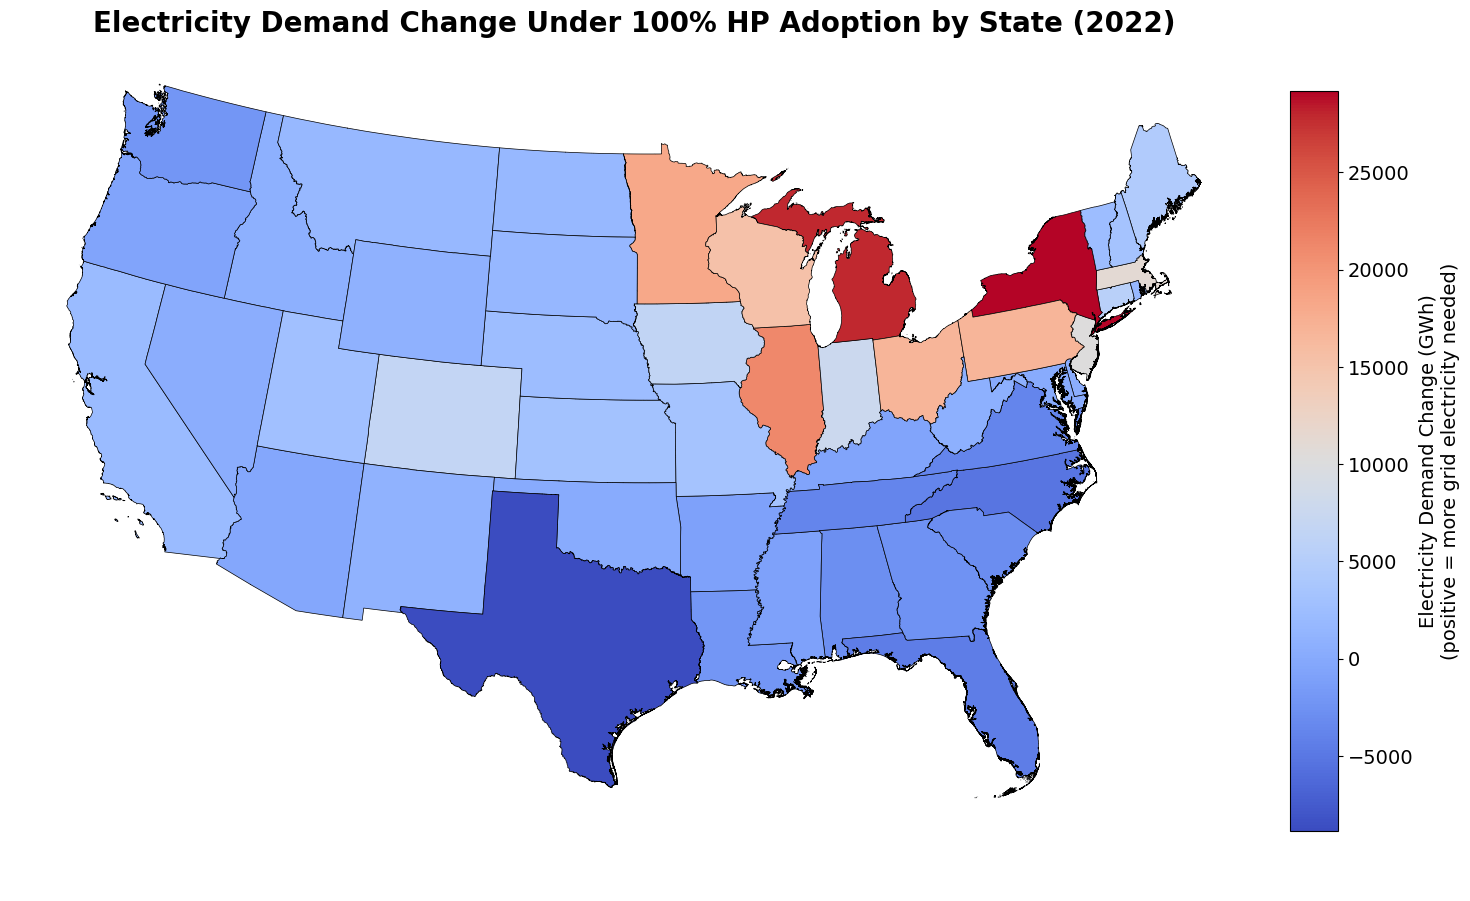

✓ Demand map generated


In [11]:
# Demand change map (diverging)
if gdf_conus is not None and gdf_alaska is not None:
    _, gdf_demand_conus, gdf_demand_alaska = prepare_state_geodataframe(
        gdf_states_raw, df_demand_state, merge_col='state'
    )
    create_choropleth_map(
        gdf_demand_conus, gdf_demand_alaska,
        column='elec_change_gwh',
        title='Electricity Demand Change Under 100% HP Adoption by State (2022)',
        cbar_label='Electricity Demand Change (GWh)\n(positive = more grid electricity needed)',
        output_path=os.path.join(PROJECT_ROOT, "state_elec_demand_change_map_2022.png"),
        cmap='coolwarm', show_plot=True,
    )
    print("✓ Demand map generated")
else:
    print("⚠ Maps skipped")

Generating bill savings and NPV choropleth maps...
  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_bill_savings_ratio_map_2022_MP4.png


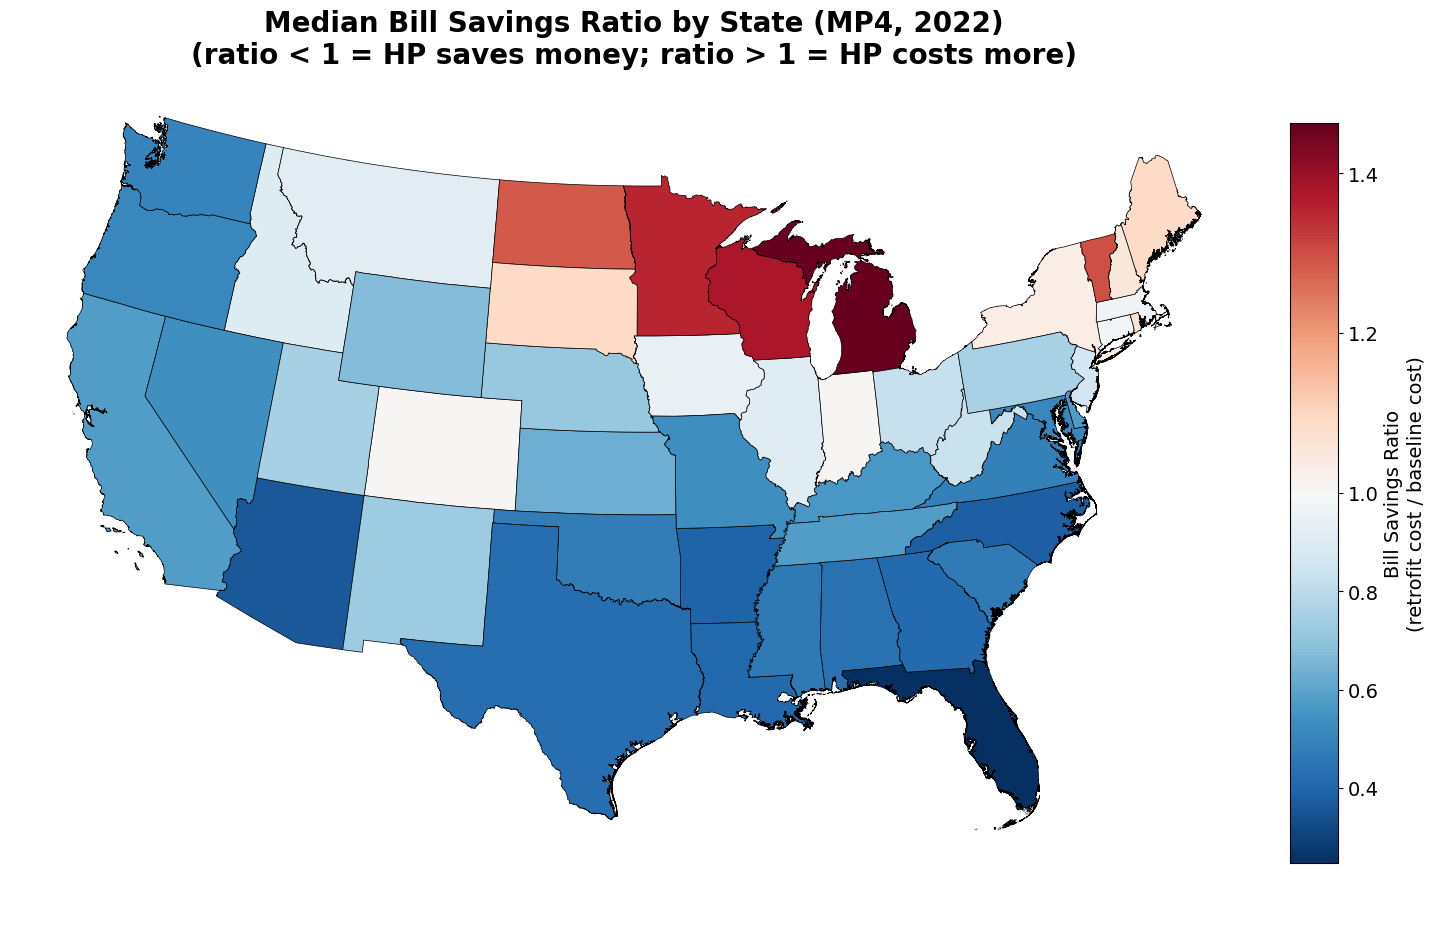

  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_private_npv_map_2022_MP4.png


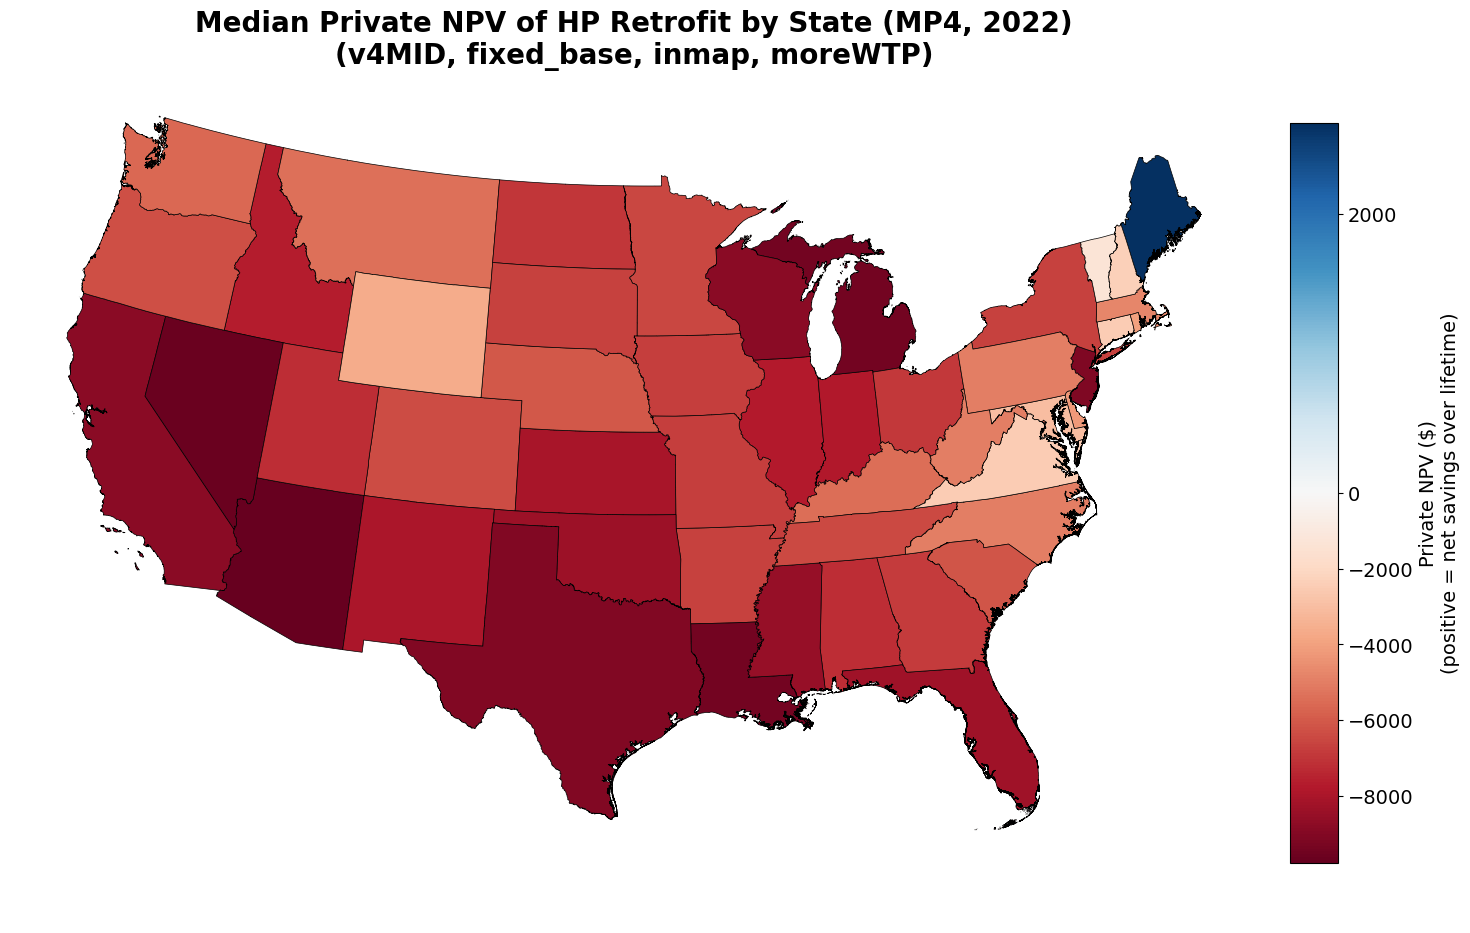

✓ Bill savings ratio and NPV maps generated


In [12]:
# ============================================================================
# STEP 6b: BILL SAVINGS RATIO AND NPV CHOROPLETH MAPS
# ============================================================================

if gdf_conus is not None and gdf_alaska is not None:
    print("Generating bill savings and NPV choropleth maps...")

    # --- Merge bill savings ratio data with geodata ---
    _, gdf_ratio_conus, gdf_ratio_alaska = prepare_state_geodataframe(
        gdf_states_raw, df_ratio_state, merge_col='state'
    )

    # --- Map 1: Median Bill Savings Ratio (diverging, centered at 1.0) ---
    ratio_vals = pd.concat([
        gdf_ratio_conus['median_bill_savings_ratio'],
        gdf_ratio_alaska['median_bill_savings_ratio']
    ]).dropna()

    ratio_map_path = os.path.join(
        PROJECT_ROOT, f"state_bill_savings_ratio_map_2022_MP{primary_mp}.png"
    )
    create_choropleth_map(
        gdf_ratio_conus, gdf_ratio_alaska,
        column='median_bill_savings_ratio',
        title=(
            f'Median Bill Savings Ratio by State (MP{primary_mp}, 2022)\n'
            '(ratio < 1 = HP saves money; ratio > 1 = HP costs more)'
        ),
        cbar_label='Bill Savings Ratio\n(retrofit cost / baseline cost)',
        output_path=ratio_map_path,
        cmap='RdBu_r',
        norm=mcolors.TwoSlopeNorm(
            vmin=ratio_vals.min(),
            vcenter=1.0,
            vmax=ratio_vals.max(),
        ),
        show_plot=True,
    )

    # --- Merge NPV data with geodata ---
    _, gdf_npv_conus, gdf_npv_alaska = prepare_state_geodataframe(
        gdf_states_raw, df_npv_state, merge_col='state'
    )

    # --- Map 2: Median Private NPV (diverging, centered at 0) ---
    npv_vals = pd.concat([
        gdf_npv_conus['median_npv'],
        gdf_npv_alaska['median_npv']
    ]).dropna()

    npv_map_path = os.path.join(
        PROJECT_ROOT, f"state_private_npv_map_2022_MP{primary_mp}.png"
    )

    # Build norm: use TwoSlopeNorm centered at 0 only if data spans both sides;
    # otherwise fall back to a linear norm.
    npv_min, npv_max = npv_vals.min(), npv_vals.max()
    if npv_min < 0 < npv_max:
        npv_norm = mcolors.TwoSlopeNorm(vmin=npv_min, vcenter=0, vmax=npv_max)
    else:
        npv_norm = mcolors.Normalize(vmin=npv_min, vmax=npv_max)

    create_choropleth_map(
        gdf_npv_conus, gdf_npv_alaska,
        column='median_npv',
        title=(
            f'Median Private NPV of HP Retrofit by State (MP{primary_mp}, 2022)\n'
            f'({cost_scenario}, {discount_rate_key}, {rcm_model}, {wtp_scenario})'
        ),
        cbar_label='Private NPV ($)\n(positive = net savings over lifetime)',
        output_path=npv_map_path,
        cmap='RdBu',  # NOTE: RdBu (not _r) so blue=positive, red=negative
        norm=npv_norm,
        show_plot=True,
    )

    print("✓ Bill savings ratio and NPV maps generated")
else:
    print("⚠ Maps skipped — geodataframe not available")

---
## Display Results
---

In [13]:
print("===== PRICE RATIOS (2022 nominal) =====\n")
display(df_prices_csv)

for mp in selected_mps:
    print(f"\n===== THERMAL COP & AFUE (MP{mp}, NG homes) =====\n")
    display(cop_results[mp].sort_values('thermal_cop', ascending=False)[
        ['state', 'thermal_cop', 'baseline_afue', 'fans_pumps_pct', 'home_count']
    ])

print(f"\n===== BILL IMPACT RATIO (MP{primary_mp}) =====\n")
display(df_spark[['state', 'state_name', 'spark_gap', 'thermal_cop', 'baseline_afue', 'bill_impact_ratio']])

# ============================================================================
# DISPLAY: BILL SAVINGS RATIO
# ============================================================================

print(f"\n===== BILL SAVINGS RATIO (MP{primary_mp}, NG homes, median per state) =====\n")

print(f"  States where median home saves money (ratio < 1): "
      f"{(df_ratio_state['median_bill_savings_ratio'] < 1.0).sum()} / {len(df_ratio_state)}")
print(f"  National median ratio: {df_ratio_state['median_bill_savings_ratio'].median():.3f}")
print(f"  Range: {df_ratio_state['median_bill_savings_ratio'].min():.3f} - "
      f"{df_ratio_state['median_bill_savings_ratio'].max():.3f}")

print(f"\n--- Top 5 States (Best for Electrification — lowest bill savings ratio) ---")
top5_ratio = df_ratio_state.nsmallest(5, 'median_bill_savings_ratio')
print(top5_ratio[['state', 'median_bill_savings_ratio', 'median_annual_savings',
                   'weighted_ratio', 'home_count']].to_string(index=False))

print(f"\n--- Bottom 5 States (Worst for Electrification — highest bill savings ratio) ---")
bot5_ratio = df_ratio_state.nlargest(5, 'median_bill_savings_ratio')
print(bot5_ratio[['state', 'median_bill_savings_ratio', 'median_annual_savings',
                   'weighted_ratio', 'home_count']].to_string(index=False))

# ============================================================================
# DISPLAY: PRIVATE NPV
# ============================================================================

print(f"\n===== PRIVATE NPV (MP{primary_mp}, median per state) =====\n")
print(f"  TARE model parameters: {cost_scenario}, {discount_rate_key}, {rcm_model}, {wtp_scenario}")
print(f"  States with positive median NPV: "
      f"{(df_npv_state['median_npv'] > 0).sum()} / {len(df_npv_state)}")
print(f"  National median NPV: ${df_npv_state['median_npv'].median():,.0f}")
print(f"  Range: ${df_npv_state['median_npv'].min():,.0f} - "
      f"${df_npv_state['median_npv'].max():,.0f}")

print(f"\n--- Top 5 States (Highest Private NPV) ---")
top5_npv = df_npv_state.nlargest(5, 'median_npv')
print(top5_npv[['state', 'median_npv', 'mean_npv',
                'median_total_capital', 'home_count']].to_string(index=False))

print(f"\n--- Bottom 5 States (Lowest Private NPV) ---")
bot5_npv = df_npv_state.nsmallest(5, 'median_npv')
print(bot5_npv[['state', 'median_npv', 'mean_npv',
                'median_total_capital', 'home_count']].to_string(index=False))

# ============================================================================
# DISPLAY: DEMAND CHANGE
# ============================================================================

print(f"\n===== DEMAND CHANGE (MP{primary_mp}, GWh, all fuels, 100% adoption) =====\n")
display(df_demand_state[['state', 'home_count', 'elec_change_gwh',
                          'pct_elec_demand_change', 'site_energy_change_gwh',
                          'pct_site_energy_change']])

print(f"\n✓ DISPLAY COMPLETE")

===== PRICE RATIOS (2022 nominal) =====



,state,state_name,elec_price_kwh,gas_price_kwh,elec_price_mmbtu,gas_price_mmbtu,spark_gap
0,AK,Alaska,0.2310,0.0364,67.70,10.67,6.34
1,MI,Michigan,0.1786,0.0372,52.34,10.90,4.80
2,WI,Wisconsin,0.1562,0.0373,45.78,10.92,4.19
3,NY,New York,0.2208,0.0537,64.71,15.74,4.11
4,CT,Connecticut,0.2461,0.0604,72.12,17.69,4.08
5,NJ,New Jersey,0.1674,0.0412,49.06,12.07,4.06
6,ID,Idaho,0.1037,0.0262,30.39,7.68,3.96
7,VT,Vermont,0.1993,0.0510,58.41,14.94,3.91
8,CA,California,0.2584,0.0662,75.73,19.41,3.90
9,RI,Rhode Island,0.2321,0.0597,68.02,17.50,3.89



===== THERMAL COP & AFUE (MP4, NG homes) =====



,state,thermal_cop,baseline_afue,fans_pumps_pct,home_count
3,CA,5.719542,0.801801,5.075078,24571
8,FL,5.697018,0.794453,5.459375,1084
16,LA,5.345519,0.799742,5.496742,2139
41,TX,5.303021,0.804379,5.558138,12362
0,AL,5.058210,0.805110,5.564781,1853
9,GA,5.057374,0.812388,5.699106,5111
38,SC,5.056874,0.808995,5.632238,1580
23,MS,5.024481,0.810445,5.541313,1219
6,DC,4.980642,0.752035,4.335234,338
1,AR,4.830257,0.804689,5.518244,1582



===== BILL IMPACT RATIO (MP4) =====



,state,state_name,spark_gap,thermal_cop,baseline_afue,bill_impact_ratio
0,MI,Michigan,4.80,2.829020,0.809416,1.373337
1,WI,Wisconsin,4.19,2.623592,0.804310,1.284521
2,NY,New York,4.11,3.201888,0.793466,1.018507
3,CT,Connecticut,4.08,3.594760,0.803036,0.911434
4,NJ,New Jersey,4.06,4.130790,0.795664,0.782029
5,ID,Idaho,3.96,3.594294,0.824162,0.908017
6,VT,Vermont,3.91,2.676052,0.805144,1.176402
7,CA,California,3.90,5.719542,0.801801,0.546726
8,RI,Rhode Island,3.89,3.166801,0.802848,0.986193
9,MA,Massachusetts,3.86,3.374642,0.800042,0.915108



===== BILL SAVINGS RATIO (MP4, NG homes, median per state) =====

  States where median home saves money (ratio < 1): 37 / 49
  National median ratio: 0.714
  Range: 0.248 - 1.463

--- Top 5 States (Best for Electrification — lowest bill savings ratio) ---
state  median_bill_savings_ratio  median_annual_savings  weighted_ratio  home_count
   FL                      0.248                 109.67           0.245        1098
   AZ                      0.362                  54.82           0.448        2840
   NC                      0.383                 446.85           0.377        3479
   AR                      0.394                 520.96           0.384        1582
   LA                      0.408                 234.72           0.393        2139

--- Bottom 5 States (Worst for Electrification — highest bill savings ratio) ---
state  median_bill_savings_ratio  median_annual_savings  weighted_ratio  home_count
   MI                      1.463                -460.14           1.463 

,state,home_count,elec_change_gwh,pct_elec_demand_change,site_energy_change_gwh,pct_site_energy_change
0,NY,13987,29182.74,751.11,-86382.40,-72.32
1,MI,12391,27988.32,726.82,-66351.05,-67.57
2,IL,13061,21261.30,386.71,-75161.73,-73.75
3,MN,6554,18233.15,407.06,-36256.27,-61.48
4,PA,15649,16798.58,168.14,-70173.78,-72.37
5,OH,14279,16746.75,176.25,-71527.77,-73.15
6,WI,6782,15341.45,568.65,-33127.79,-64.74
7,MA,6051,11175.78,777.87,-33828.12,-72.84
8,NJ,8390,10240.90,518.62,-45733.23,-78.92
9,IN,8124,7743.18,117.60,-37949.04,-72.59



✓ DISPLAY COMPLETE
